In [40]:
# Import the neccessary libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [41]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open (filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
    else:
        print('Download failed: ', response.status_code)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_base.csv"
filename = 'laptops.csv'

download(url, filename)

df = pd.read_csv(filename)

In [42]:
headers = [ "Manufacturer", "Category", "Screen", "GPU", "OS", "CPU_core", "Screen_Size_inch", "CPU_frequency", "RAM_GB", "Storage_GB_SSD", "Weight_kg", "Price"]
df.columns = headers

df.replace('?', np.nan, inplace=True)

df.dtypes

df['Screen_Size_inch'] = df['Screen_Size_inch'].astype('float').round(2)

df.to_csv(filename)
df.isna().sum()

Manufacturer        0
Category            0
Screen              0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    4
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_kg           5
Price               0
dtype: int64

In [43]:
mean_screen_size = df['Screen_Size_inch'].astype('float').mean(axis=0)
df['Screen_Size_inch'].replace(np.nan, mean_screen_size, inplace=True)

mean_weight = df['Weight_kg'].astype('float').mean(axis=0)
df['Weight_kg'].replace(np.nan, mean_weight, inplace=True)

df.isna().sum()

C:\Users\vppho\AppData\Local\Temp\ipykernel_12676\1374129191.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Screen_Size_inch'].replace(np.nan, mean_screen_size, inplace=True)
C:\Users\vppho\AppData\Local\Temp\ipykernel_12676\1374129191.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

Manufacturer        0
Category            0
Screen              0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    0
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_kg           0
Price               0
dtype: int64

In [44]:
# Perform Data Normalization on CPU frequency

df['CPU_frequency'] = df['CPU_frequency'] / df['CPU_frequency'].max()
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Dell,3,Full HD,1,1,3,39.62,0.689655,4,256,2.2,634
1,Dell,3,Full HD,1,1,7,39.62,0.931034,8,256,2.2,946
2,Dell,4,IPS Panel,2,1,5,33.78,0.551724,8,128,1.22,1244
3,HP,4,Full HD,2,1,7,39.62,0.620690,8,256,1.91,837
4,Dell,3,Full HD,1,1,5,39.62,0.551724,8,256,2.2,1016


Text(0.5, 1.0, 'Price binning plot')

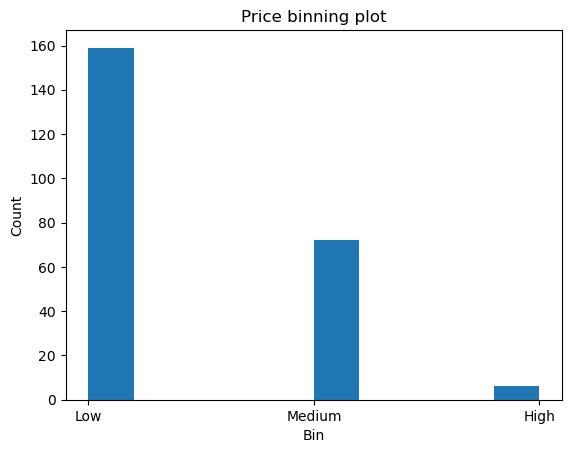

In [45]:
bins = np.linspace(min(df['Price']), max(df['Price']), 4)
labels = ['Low', 'Medium', 'High']

df['Price_binned'] = pd.cut(df['Price'], bins, labels=labels, include_lowest=True)

plt.hist(df['Price_binned'])
plt.xlabel('Bin')
plt.ylabel('Count')
plt.title('Price binning plot')

In [46]:
screen_type = pd.get_dummies(df['Screen'])
screen_type.value_counts()

df = pd.concat([df, screen_type], axis=1)
df.drop('Screen', axis=1, inplace=True)

df.to_csv('clean_laptops.csv')